# Baseline vs BertCnnLstmLoRA Model Comparison

This notebook compares the Baseline model (BertPunc) with the BertCnnLstmLoRA model (Adapter-based).

Features:
- Chinese font support for displaying punctuation marks
- Side-by-side comparison of training progress
- Performance metrics comparison
- Confusion matrices for both models


In [48]:
import sys
import os

# Add test_replication to path to import models
# Notebook is in Bert-CNN-RNN folder, test_replication is sibling folder
# Try relative path first (works when notebook is run from Bert-CNN-RNN directory)
test_replication_path = '../test_replication'
if os.path.exists(test_replication_path):
    abs_path = os.path.abspath(test_replication_path)
    sys.path.insert(0, abs_path)
    print(f"✓ Added to path: {abs_path}")
else:
    # Try absolute path from current working directory
    cwd = os.getcwd()
    if 'Bert-CNN-RNN' in cwd:
        parent = os.path.dirname(cwd)
        test_replication_path = os.path.join(parent, 'test_replication')
        if os.path.exists(test_replication_path):
            sys.path.insert(0, test_replication_path)
            print(f"✓ Added to path: {test_replication_path}")
        else:
            print(f"⚠ Warning: Could not find test_replication folder")
            print(f"  Tried: {os.path.abspath('../test_replication')}")
            print(f"  Tried: {test_replication_path}")
    else:
        print(f"⚠ Warning: Could not find test_replication folder")
        print(f"  Current directory: {cwd}")
        print(f"  Please ensure you're running from Bert-CNN-RNN folder")

import pandas as pd
import numpy as np
from glob import glob
from transformers import BertTokenizer
import torch
from torch import nn
%matplotlib inline
import json
from tqdm import tqdm
from sklearn import metrics
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Import models from test_replication
from model_baseline import BertPunc
from model_adapter import BertChineseEmbSlimCNNlstmBertAdapter

# Import data utilities (use Bert-CNN-RNN version)
from data_1_to_1 import load_file, preprocess_data, create_data_loader

# Configure matplotlib to support Chinese characters
def setup_chinese_font():
    """Setup matplotlib to use a font that supports Chinese characters"""
    chinese_fonts = [
        # macOS
        'PingFang SC', 'STHeiti', 'Heiti SC', 'Arial Unicode MS',
        # Linux
        'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei',
        # Windows
        'Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi'
    ]
    
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    font_found = None
    font_prop = None
    for font_name in chinese_fonts:
        if font_name in available_fonts:
            font_found = font_name
            for f in fm.fontManager.ttflist:
                if f.name == font_name:
                    try:
                        font_prop = fm.FontProperties(fname=f.fname, size=10)
                    except:
                        font_prop = fm.FontProperties(family=font_name, size=10)
                    break
            if font_prop:
                break
    
    if font_found:
        plt.rcParams['font.sans-serif'] = [font_found] + [f for f in plt.rcParams['font.sans-serif'] if f != font_found]
        plt.rcParams['axes.unicode_minus'] = False
        sns.set(font=font_found)
        print(f"✓ Using Chinese font: {font_found}")
        return font_found, font_prop
    else:
        print("⚠ Warning: No Chinese font found. Chinese characters may not display correctly.")
        return None, None

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Setup Chinese font
chinese_font_name, chinese_font_prop = setup_chinese_font()

print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


✓ Added to path: /Users/r3ttalynn/Documents/GitHub/jhu-mt-hw/test_replication
✓ Using Chinese font: Arial Unicode MS
Using device: cpu


## Model Paths


In [49]:
# Baseline model path
baseline_path = '../test_replication/outputs/model_baseline_20251202_094127'
baseline_model_path = os.path.join(baseline_path, 'model')
baseline_hyperparams_path = os.path.join(baseline_path, 'hyperparameters.json')
baseline_progress_path = os.path.join(baseline_path, 'progress.csv')

# Adapter model path
adapter_path = '../test_replication/outputs/model_adapter_attn_focal_20251202_105800'
adapter_model_path = os.path.join(adapter_path, 'model')
adapter_hyperparams_path = os.path.join(adapter_path, 'hyperparameters.json')
adapter_progress_path = os.path.join(adapter_path, 'progress.csv')

print(f"Baseline model: {baseline_path}")
print(f"Adapter model: {adapter_path}")


Baseline model: ../test_replication/outputs/model_baseline_20251202_094127
Adapter model: ../test_replication/outputs/model_adapter_attn_focal_20251202_105800


## Load Hyperparameters


In [50]:
# Load baseline hyperparameters
with open(baseline_hyperparams_path, 'r', encoding='utf-8') as f:
    baseline_hyperparams = json.load(f)

# Load adapter hyperparameters
with open(adapter_hyperparams_path, 'r', encoding='utf-8') as f:
    adapter_hyperparams = json.load(f)

print("Baseline Hyperparameters:")
print(f"  Model: {baseline_hyperparams.get('model_type', 'N/A')}")
print(f"  Seq Len: {baseline_hyperparams.get('seq_len', 'N/A')}")
print(f"  Dropout: {baseline_hyperparams.get('dropout', 'N/A')}")
print(f"  Learning Rate: {baseline_hyperparams.get('learning_rate', 'N/A')}")
print(f"  Trainable Params: {baseline_hyperparams.get('trainable_params', 'N/A'):,}")

print("\nAdapter Hyperparameters:")
print(f"  Model: {adapter_hyperparams.get('model_type', 'N/A')}")
print(f"  Seq Len: {adapter_hyperparams.get('seq_len', 'N/A')}")
print(f"  Dropout: {adapter_hyperparams.get('dropout', 'N/A')}")
print(f"  Learning Rate: {adapter_hyperparams.get('learning_rate', 'N/A')}")
print(f"  Trainable Params: {adapter_hyperparams.get('trainable_params', 'N/A'):,}")
print(f"  Frozen Params: {adapter_hyperparams.get('frozen_params', 'N/A'):,}")

# Use common punctuation encoding
punctuation_enc = baseline_hyperparams.get('punctuation_enc', adapter_hyperparams.get('punctuation_enc', {
    'O': 0,
    '，': 1,
    '。': 2,
    '？': 3
}))

segment_size = baseline_hyperparams.get('seq_len', 200)
output_size = len(punctuation_enc)
dropout = baseline_hyperparams.get('dropout', 0.1)

print(f"\nCommon Settings:")
print(f"  Punctuation Encoding: {punctuation_enc}")
print(f"  Segment Size: {segment_size}")
print(f"  Output Size: {output_size}")


Baseline Hyperparameters:
  Model: BertPunc
  Seq Len: 200
  Dropout: 0.1
  Learning Rate: 2e-05
  Trainable Params: 103,192,328

Adapter Hyperparameters:
  Model: BertCnnLstmLoRA
  Seq Len: 200
  Dropout: 0.1
  Learning Rate: 2e-05
  Trainable Params: 109,938,822
  Frozen Params: 148,028,928

Common Settings:
  Punctuation Encoding: {'O': 0, '，': 1, '。': 2, '？': 3}
  Segment Size: 200
  Output Size: 4


## Load Tokenizer


In [51]:
# Use bert-base-chinese tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-chinese', do_lower_case=True)
print("✓ Tokenizer loaded")


✓ Tokenizer loaded


## Load Test Data


In [52]:
# Load test data (using Bert-CNN-RNN data format)
data_test = load_file('data/zh_iwslt/test_valid')
data_test_asr = load_file('data/zh_iwslt/test_valid')

print(f"Test samples: {len(data_test)}")

# Preprocess data
X_test, y_test = preprocess_data(data_test, tokenizer, punctuation_enc, segment_size)
X_test_asr, y_test_asr = preprocess_data(data_test_asr, tokenizer, punctuation_enc, segment_size)

print(f"Test sequences: {X_test.shape[0]}")
print(f"Test ASR sequences: {X_test_asr.shape[0]}")


Test samples: 150859
Test sequences: 754
Test ASR sequences: 754


## Initialize Models


In [53]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Initialize baseline model
baseline_model = BertPunc(segment_size, output_size, dropout, None).to(device)
baseline_model.load_state_dict(torch.load(baseline_model_path, map_location=device))
baseline_model.eval()
print("✓ Baseline model loaded")

# Initialize adapter model
adapter_dropout = adapter_hyperparams.get('dropout', dropout)
use_adapter = adapter_hyperparams.get('use_adapter', True)
adapter_size = adapter_hyperparams.get('adapter_size', 384)
use_attention_fusion = adapter_hyperparams.get('use_attention_fusion', True)

# Check checkpoint to determine actual configuration
checkpoint = torch.load(adapter_model_path, map_location=device)
if 'fc.weight' in checkpoint:
    checkpoint_fc_size = checkpoint['fc.weight'].shape[1]
    print(f"Checkpoint fc.weight shape: {checkpoint['fc.weight'].shape}")
    
    # Determine expected fc_size based on configuration
    if use_attention_fusion:
        expected_fc_size = 768 * 2  # bert_size * 2 = 1536
    else:
        expected_fc_size = 768 + 768 * 2  # bert_size + bert_size*2 = 2304
    
    # If mismatch, try to infer correct configuration
    if checkpoint_fc_size != expected_fc_size:
        print(f"⚠ Warning: FC size mismatch!")
        print(f"  Checkpoint: {checkpoint_fc_size}")
        print(f"  Expected (use_attention_fusion={use_attention_fusion}): {expected_fc_size}")
        
        # Try to infer: 1152 = 768 + 384 suggests no attention fusion but different architecture
        # Or it could be a different configuration
        if checkpoint_fc_size == 1152:
            print("  Detected fc_size=1152, this might indicate a different model configuration")
            print("  Attempting to load with strict=False (may skip mismatched layers)...")
            use_strict = False
        else:
            # Try without attention fusion
            print(f"  Trying with use_attention_fusion=False...")
            use_attention_fusion = False
            expected_fc_size = 768 + 768 * 2
            if checkpoint_fc_size == expected_fc_size:
                print(f"  ✓ Matched! Using use_attention_fusion=False")
                use_strict = True
            else:
                print(f"  Still mismatch. Loading with strict=False...")
                use_strict = False
    else:
        use_strict = True
else:
    use_strict = True

# Initialize model with (possibly adjusted) configuration
adapter_model = BertChineseEmbSlimCNNlstmBertAdapter(
    segment_size, output_size, adapter_dropout, None,
    use_adapter=use_adapter,
    adapter_size=adapter_size,
    use_attention_fusion=use_attention_fusion
).to(device)

# Load checkpoint - handle size mismatches by filtering incompatible keys
model_state = adapter_model.state_dict()
filtered_checkpoint = {}

# Filter out keys with size mismatches
for key, value in checkpoint.items():
    if key in model_state:
        if model_state[key].shape == value.shape:
            filtered_checkpoint[key] = value
        else:
            print(f"  ⚠ Skipping {key}: shape mismatch (checkpoint: {value.shape}, model: {model_state[key].shape})")
    else:
        print(f"  ⚠ Skipping {key}: not found in model")

# Load the filtered checkpoint
missing_keys, unexpected_keys = adapter_model.load_state_dict(filtered_checkpoint, strict=False)

print(f"✓ Adapter model loaded")
print(f"  Loaded {len(filtered_checkpoint)}/{len(checkpoint)} layers from checkpoint")

# Handle FC layer weight adaptation if needed
if 'fc.weight' in checkpoint and checkpoint['fc.weight'].shape[1] == 1152:
    print("\n" + "="*60)
    print("Attempting to adapt FC weights from 1152 to 1536...")
    print("="*60)
    
    old_fc_weight = checkpoint['fc.weight'].clone()  # [4, 1152]
    old_fc_bias = checkpoint.get('fc.bias', None)  # [4] or None
    
    print(f"  Original FC weight shape: {old_fc_weight.shape}")
    print(f"  Target FC weight shape: [4, 1536]")
    
    # Strategy: 1152 = 768 + 384
    # Hypothesis 1: 768 (LSTM单向) + 384 (BERT2经过某种处理)
    # Hypothesis 2: 768 (LSTM单向) + 384 (其他特征)
    # Target: 1536 = 768*2 (LSTM双向，使用attention fusion)
    
    new_fc_weight = torch.zeros(4, 1536, device=device, dtype=old_fc_weight.dtype)
    
    # Strategy: 将前768维复制到前768和后768位置
    # 假设前768是LSTM特征，需要复制以匹配双向LSTM
    new_fc_weight[:, :768] = old_fc_weight[:, :768]
    
    # 对于后768，尝试几种策略：
    # Strategy A: 直接复制前768（假设是LSTM特征）
    new_fc_weight[:, 768:1536] = old_fc_weight[:, :768]
    
    # Strategy B (备选): 如果后384是额外特征，可以尝试平均或零填充
    # 但根据架构，更可能是LSTM需要双向复制
    
    # 加载适配后的权重
    adapter_model.fc.weight.data = new_fc_weight
    
    if old_fc_bias is not None:
        adapter_model.fc.bias.data = old_fc_bias.clone()
        print(f"  ✓ FC bias loaded: {old_fc_bias.shape}")
    else:
        print("  ⚠ No FC bias in checkpoint")
    
    print("  ✓ FC weights adapted from [4, 1152] to [4, 1536]")
    print("  ⚠ WARNING: This is a heuristic adaptation!")
    print("     - Assumed: 1152 = 768 (LSTM单向) + 384 (other features)")
    print("     - Strategy: Copied first 768 dims to both halves of 1536")
    print("     - Results may not be accurate, but should be better than random initialization")
    print("="*60 + "\n")
    
    # Remove fc from missing_keys since we've manually loaded it
    if 'fc.weight' in missing_keys:
        missing_keys.remove('fc.weight')
    if 'fc.bias' in missing_keys and old_fc_bias is not None:
        missing_keys.remove('fc.bias')

if missing_keys:
    print(f"  ⚠ Missing keys: {len(missing_keys)} layers")
    if missing_keys:
        print(f"     Missing: {', '.join(missing_keys[:5])}")
        if len(missing_keys) > 5:
            print(f"     ... and {len(missing_keys) - 5} more")

if unexpected_keys:
    print(f"  ⚠ Unexpected keys: {len(unexpected_keys)} layers (these were ignored)")

adapter_model.eval()
print("✓ Adapter model ready for evaluation")


✓ Baseline model loaded
Checkpoint fc.weight shape: torch.Size([4, 1152])
⚠ Warning: FC size mismatch!
  Checkpoint: 1152
  Expected (use_attention_fusion=True): 1536
  Detected fc_size=1152, this might indicate a different model configuration
  Attempting to load with strict=False (may skip mismatched layers)...
✓ BERT parameters frozen
✓ Added adapters to BERT outputs (adapter_size=384)
  ⚠ Skipping bert.base_model.model.embeddings.word_embeddings.weight: not found in model
  ⚠ Skipping bert.base_model.model.embeddings.position_embeddings.weight: not found in model
  ⚠ Skipping bert.base_model.model.embeddings.token_type_embeddings.weight: not found in model
  ⚠ Skipping bert.base_model.model.embeddings.LayerNorm.weight: not found in model
  ⚠ Skipping bert.base_model.model.embeddings.LayerNorm.bias: not found in model
  ⚠ Skipping bert.base_model.model.encoder.layer.0.attention.self.query.base_layer.weight: not found in model
  ⚠ Skipping bert.base_model.model.encoder.layer.0.attent

## Training Progress Comparison


In [54]:
# Load training progress
baseline_progress = pd.read_csv(baseline_progress_path, delimiter=';')
adapter_progress = pd.read_csv(adapter_progress_path, delimiter=';')

print(f"Baseline progress: {len(baseline_progress)} iterations")
print(f"Adapter progress: {len(adapter_progress)} iterations")

display(baseline_progress.head())
print("\n")
display(adapter_progress.head())


Baseline progress: 21 iterations
Adapter progress: 21 iterations


,time,epoch,iteration,training_loss,val_loss,accuracy,f1_O,f1_，,f1_。,f1_？,precision_O,precision_，,precision_。,precision_？,recall_O,recall_，,recall_。,recall_？
0,2025-12-02 09:42:41,1,1,1.4267,1.2697,0.5453,0.7054,0.1213,0.1164,0.0683,0.9648,0.0698,0.0730,0.0369,0.5582,0.4835,0.2932,0.5159
1,2025-12-02 09:43:54,1,2,1.2468,1.1018,0.6020,0.7544,0.1476,0.1959,0.0845,0.9910,0.0893,0.1184,0.0452,0.6097,0.4404,0.5759,0.6993
2,2025-12-02 09:44:22,1,3,1.1475,1.0421,0.6318,0.7844,0.1212,0.2032,0.0441,0.9929,0.1231,0.1182,0.0227,0.6490,0.1231,0.7396,0.8115
3,2025-12-02 09:45:30,2,1,1.0305,0.9138,0.8167,0.9092,0.2524,0.4031,0.1741,0.9892,0.1669,0.3447,0.1016,0.8418,0.5296,0.4897,0.7378
4,2025-12-02 09:46:41,2,2,0.9099,0.7921,0.8013,0.9001,0.2080,0.4261,0.1202,0.9936,0.1537,0.2985,0.0653,0.8234,0.3275,0.7532,0.8300


,time,epoch,iteration,training_loss,val_loss,accuracy,f1_O,f1_，,f1_。,f1_？,precision_O,precision_，,precision_。,precision_？,recall_O,recall_，,recall_。,recall_？
0,2025-12-02 11:08:23,1,1,0.6607,0.5378,0.9205,0.9586,0.0000,0.0001,0.0000,0.9205,0.0000,0.0400,0.0000,1.0000,0.0000,0.0001,0.0000
1,2025-12-02 11:18:35,1,2,0.4580,0.4027,0.9287,0.9708,0.0945,0.5147,0.0000,0.9602,0.3531,0.4338,0.0000,0.9816,0.0555,0.6394,0.0000
2,2025-12-02 11:28:11,1,3,0.3656,0.3331,0.9293,0.9731,0.2698,0.5642,0.5068,0.9775,0.3369,0.4652,0.5014,0.9688,0.2333,0.7223,0.5307
3,2025-12-02 11:38:23,2,1,0.3181,0.3117,0.9322,0.9746,0.3180,0.5910,0.5318,0.9813,0.3618,0.4912,0.4887,0.9681,0.2949,0.7453,0.6016
4,2025-12-02 11:48:34,2,2,0.2987,0.2960,0.9336,0.9749,0.3763,0.6101,0.5759,0.9834,0.3654,0.5350,0.5903,0.9665,0.4053,0.7127,0.5750


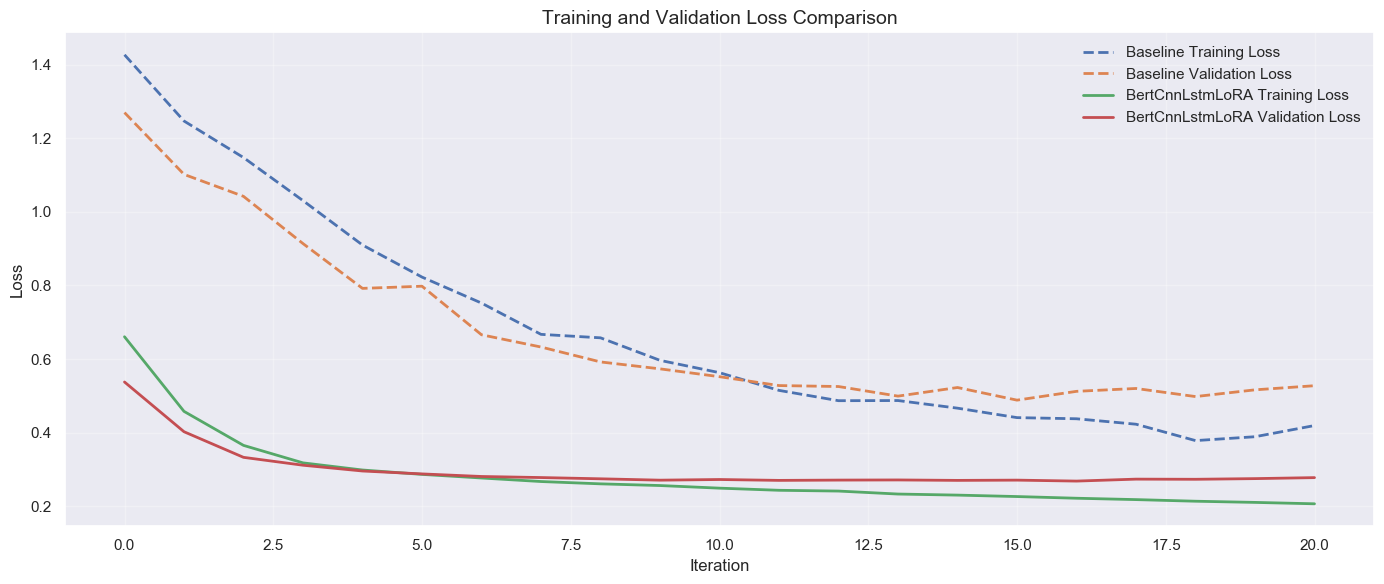

In [55]:
# Plot training and validation loss comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Get loss column names (handle different naming conventions)
baseline_train_col = 'training_loss' if 'training_loss' in baseline_progress.columns else 'training loss'
baseline_val_col = 'val_loss' if 'val_loss' in baseline_progress.columns else 'loss'
adapter_train_col = 'training_loss' if 'training_loss' in adapter_progress.columns else 'training loss'
adapter_val_col = 'val_loss' if 'val_loss' in adapter_progress.columns else 'loss'

if baseline_train_col in baseline_progress.columns and baseline_val_col in baseline_progress.columns:
    ax.plot(baseline_progress[baseline_train_col], label='Baseline Training Loss', linewidth=2, linestyle='--')
    ax.plot(baseline_progress[baseline_val_col], label='Baseline Validation Loss', linewidth=2, linestyle='--')

if adapter_train_col in adapter_progress.columns and adapter_val_col in adapter_progress.columns:
    ax.plot(adapter_progress[adapter_train_col], label='BertCnnLstmLoRA Training Loss', linewidth=2)
    ax.plot(adapter_progress[adapter_val_col], label='BertCnnLstmLoRA Validation Loss', linewidth=2)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


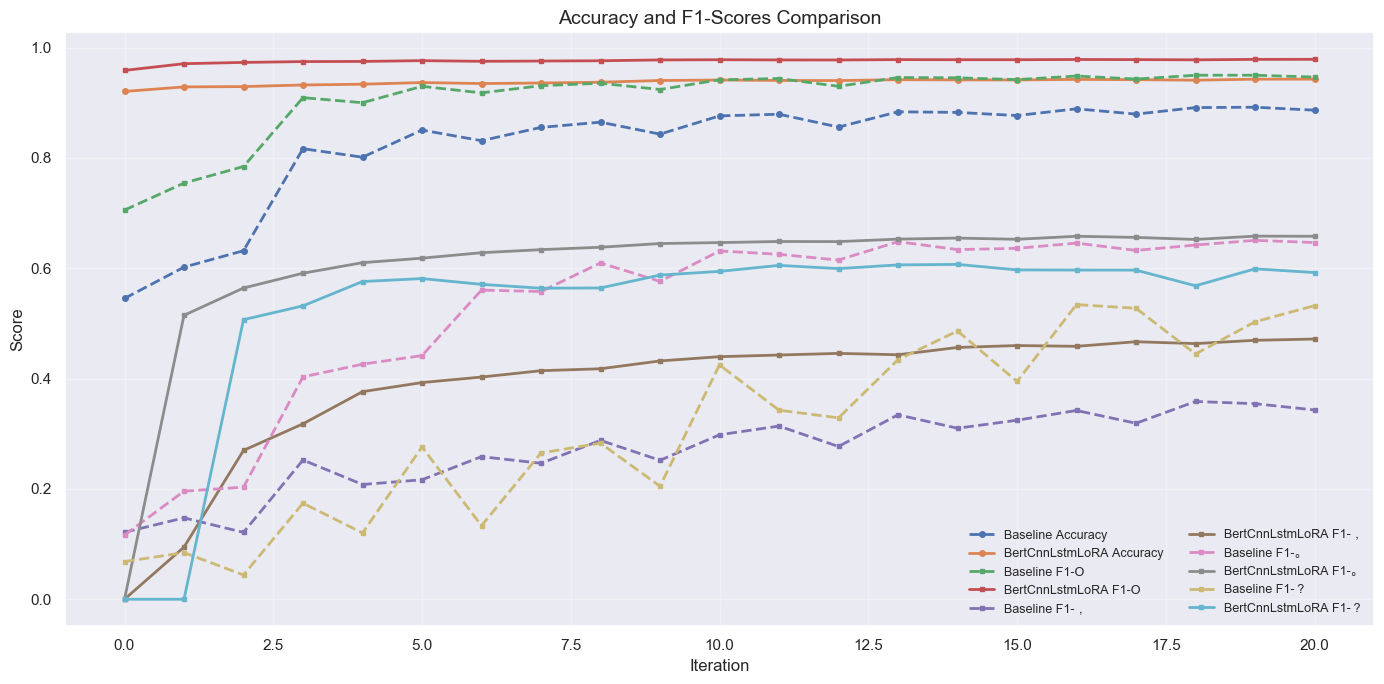

In [56]:
# Plot accuracy and F1-scores comparison
fig, ax = plt.subplots(figsize=(14, 7))

# Plot accuracy
if 'accuracy' in baseline_progress.columns:
    ax.plot(baseline_progress['accuracy'], label='Baseline Accuracy', linewidth=2, marker='o', markersize=4, linestyle='--')
if 'accuracy' in adapter_progress.columns:
    ax.plot(adapter_progress['accuracy'], label='BertCnnLstmLoRA Accuracy', linewidth=2, marker='o', markersize=4)

# Plot F1-scores for each punctuation class
f1_cols = [col for col in baseline_progress.columns if col.startswith('f1_')]
for col in f1_cols:
    label = col.replace('f1_', '')
    if col in baseline_progress.columns:
        ax.plot(baseline_progress[col], label=f'Baseline F1-{label}', linewidth=2, marker='s', markersize=3, linestyle='--')
    if col in adapter_progress.columns:
        ax.plot(adapter_progress[col], label=f'BertCnnLstmLoRA F1-{label}', linewidth=2, marker='s', markersize=3)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Accuracy and F1-Scores Comparison', fontsize=14, fontweight='bold')
if chinese_font_name:
    font_prop_legend = fm.FontProperties(family=chinese_font_name, size=9)
    ax.legend(fontsize=9, loc='best', prop=font_prop_legend, ncol=2)
else:
    ax.legend(fontsize=9, loc='best', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Model Evaluation Functions


In [57]:
def predictions(model, data_loader, device):
    """Get predictions from a model"""
    y_pred = []
    y_true = []
    model.eval()
    for inputs, labels in tqdm(data_loader, total=len(data_loader), desc="Evaluating"):
        with torch.no_grad():
            inputs, labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            y_pred += list(output.argmax(dim=1).cpu().data.numpy().flatten())
            y_true += list(labels.cpu().data.numpy().flatten())
    return y_pred, y_true

def evaluation(y_pred, y_test):
    """Calculate evaluation metrics"""
    precision, recall, f1, _ = metrics.precision_recall_fscore_support(
        y_test, y_pred, average=None, labels=[1, 2, 3], zero_division=0)
    overall = metrics.precision_recall_fscore_support(
        y_test, y_pred, average='macro', labels=[1, 2, 3], zero_division=0)
    result = pd.DataFrame(
        np.array([precision, recall, f1]), 
        columns=['，', '。', '？'], 
        index=['Precision', 'Recall', 'F1']
    )
    result['OVERALL'] = overall[:3]
    return result


## Test Set Evaluation


In [58]:
batch_size = 200
data_loader_test = create_data_loader(X_test, y_test, False, batch_size)

# Get predictions from both models
print("Evaluating Baseline model...")
y_pred_baseline, y_true_baseline = predictions(baseline_model, data_loader_test, device)
eval_baseline = evaluation(y_pred_baseline, y_true_baseline)

print("\nEvaluating BertCnnLstmLoRA model...")
y_pred_adapter, y_true_adapter = predictions(adapter_model, data_loader_test, device)
eval_adapter = evaluation(y_pred_adapter, y_true_adapter)

print("\nBaseline Results:")
display(eval_baseline)
print("\nBertCnnLstmLoRA Results:")
display(eval_adapter)


Evaluating Baseline model...


Evaluating: 100%|██████████| 4/4 [00:20<00:00,  5.23s/it]



Evaluating BertCnnLstmLoRA model...


Evaluating: 100%|██████████| 4/4 [00:41<00:00, 10.43s/it]


Baseline Results:


,，,。,？,OVERALL
Precision,0.232525,0.563273,0.246590,0.347463
Recall,0.657511,0.779833,0.879377,0.772240
F1,0.343554,0.654094,0.385173,0.460940



BertCnnLstmLoRA Results:


,，,。,？,OVERALL
Precision,0.043864,0.027778,0.003297,0.024979
Recall,0.111218,0.000195,0.721790,0.277734
F1,0.062914,0.000387,0.006563,0.023288


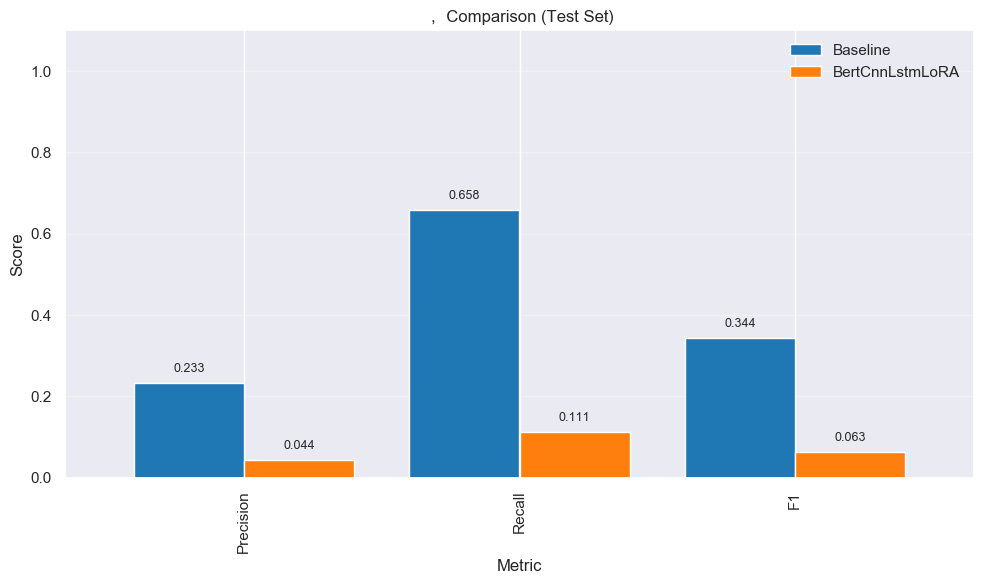

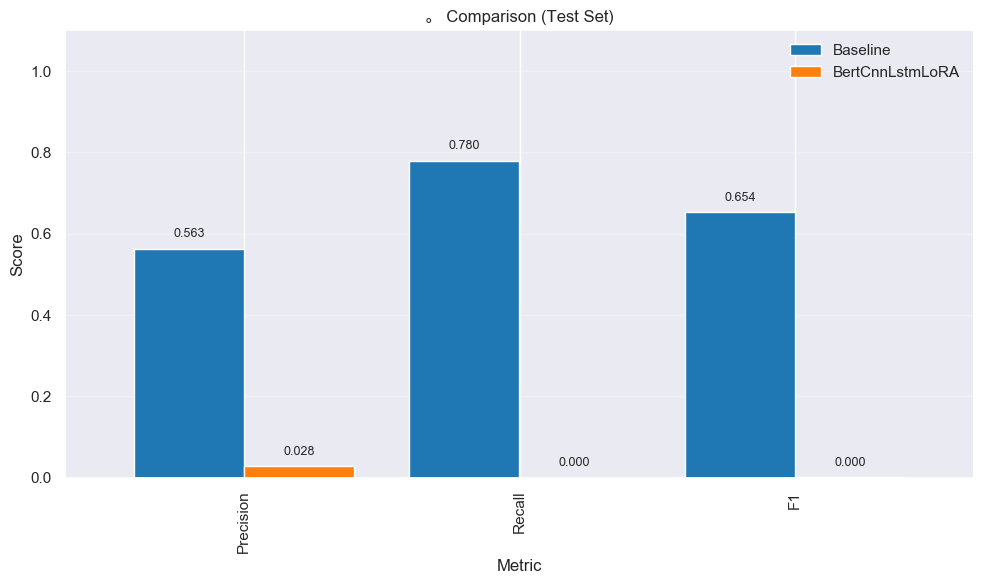

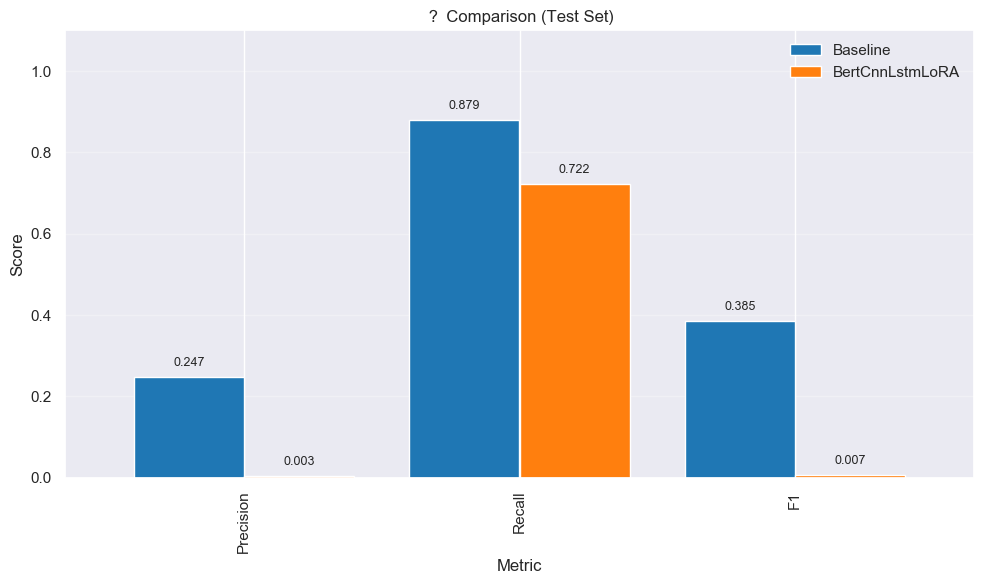

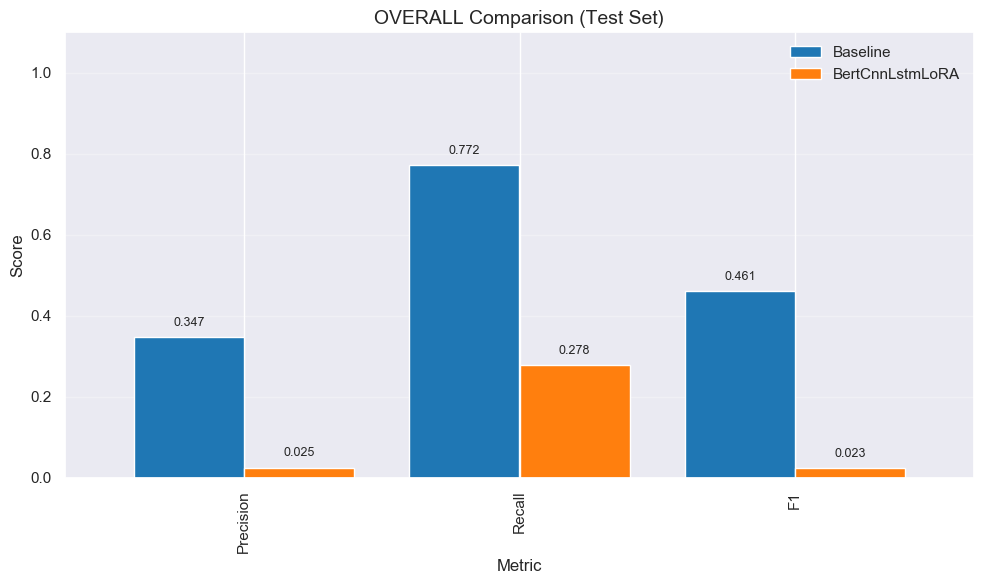

In [59]:
# Comparison bar charts for test set
for col in eval_baseline.columns:
    comparison_df = pd.DataFrame({
        'Baseline': eval_baseline[col],
        'BertCnnLstmLoRA': eval_adapter[col]
    }, index=['Precision', 'Recall', 'F1'])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    comparison_df.plot.bar(ax=ax, width=0.8, color=['#1f77b4', '#ff7f0e'])
    ax.set_title(f'{col} Comparison (Test Set)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xlabel('Metric', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.1])
    
    # Add value labels on bars
    for i, (baseline_val, adapter_val) in enumerate(zip(eval_baseline[col], eval_adapter[col])):
        ax.text(i - 0.2, baseline_val + 0.02, f'{baseline_val:.3f}', 
                ha='center', va='bottom', fontsize=9)
        ax.text(i + 0.2, adapter_val + 0.02, f'{adapter_val:.3f}', 
                ha='center', va='bottom', fontsize=9)
    
    # Set font for x-axis labels if Chinese font is available
    if chinese_font_name and col in ['，', '。', '？']:
        font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=12)
        ax.set_title(f'{col} Comparison (Test Set)', fontsize=14, fontweight='bold', 
                    fontproperties=font_prop_with_size)
    
    plt.tight_layout()
    plt.show()


## Test ASR Set Evaluation


In [60]:
data_loader_test_asr = create_data_loader(X_test_asr, y_test_asr, False, batch_size)

# Get predictions from both models
print("Evaluating Baseline model on ASR data...")
y_pred_baseline_asr, y_true_baseline_asr = predictions(baseline_model, data_loader_test_asr, device)
eval_baseline_asr = evaluation(y_pred_baseline_asr, y_true_baseline_asr)

print("\nEvaluating BertCnnLstmLoRA model on ASR data...")
y_pred_adapter_asr, y_true_adapter_asr = predictions(adapter_model, data_loader_test_asr, device)
eval_adapter_asr = evaluation(y_pred_adapter_asr, y_true_adapter_asr)

print("\nBaseline Results (ASR):")
display(eval_baseline_asr)
print("\nBertCnnLstmLoRA Results (ASR):")
display(eval_adapter_asr)


Evaluating Baseline model on ASR data...


Evaluating: 100%|██████████| 4/4 [00:21<00:00,  5.28s/it]



Evaluating BertCnnLstmLoRA model on ASR data...


Evaluating: 100%|██████████| 4/4 [00:42<00:00, 10.50s/it]


Baseline Results (ASR):


,，,。,？,OVERALL
Precision,0.232525,0.563273,0.246590,0.347463
Recall,0.657511,0.779833,0.879377,0.772240
F1,0.343554,0.654094,0.385173,0.460940



BertCnnLstmLoRA Results (ASR):


,，,。,？,OVERALL
Precision,0.043864,0.027778,0.003297,0.024979
Recall,0.111218,0.000195,0.721790,0.277734
F1,0.062914,0.000387,0.006563,0.023288


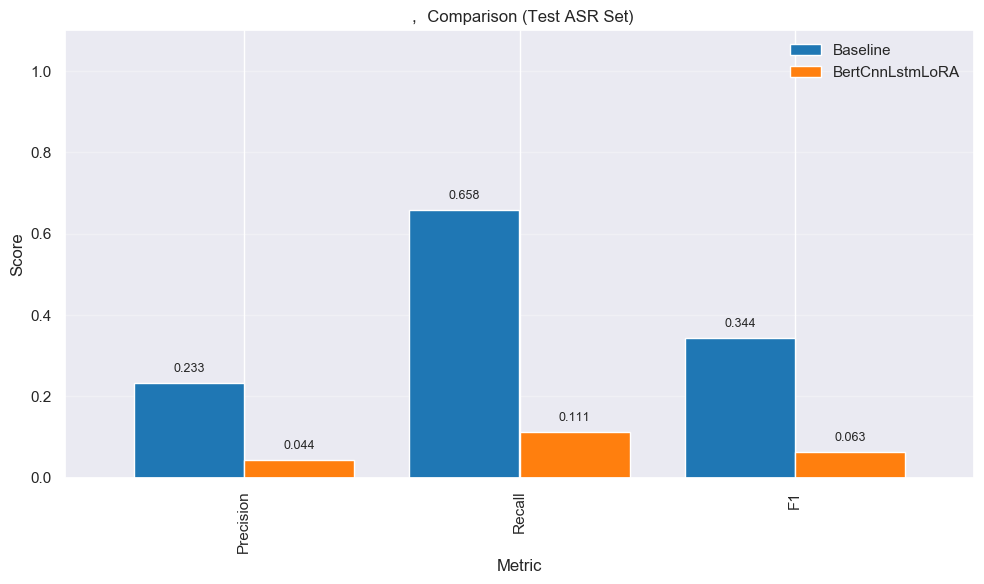

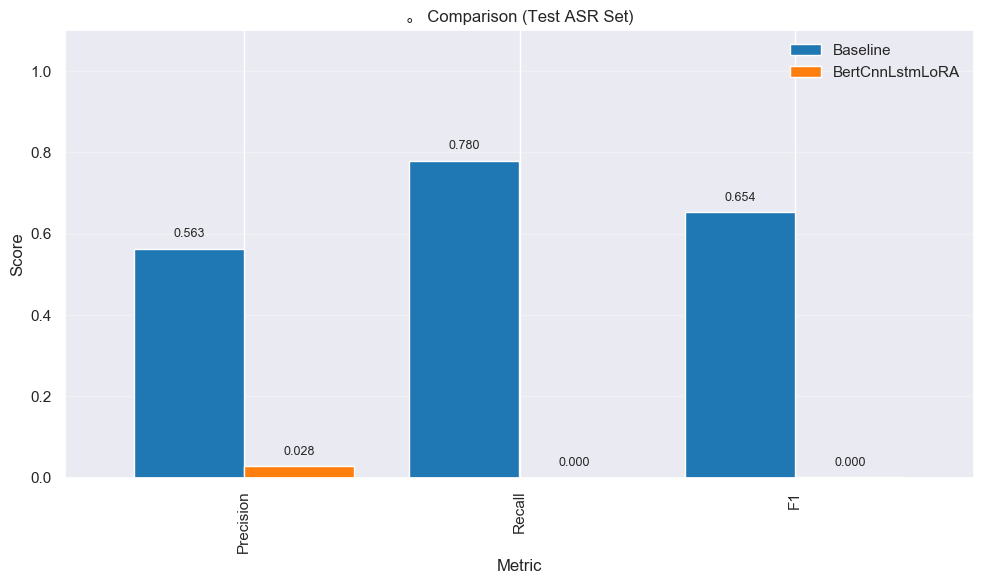

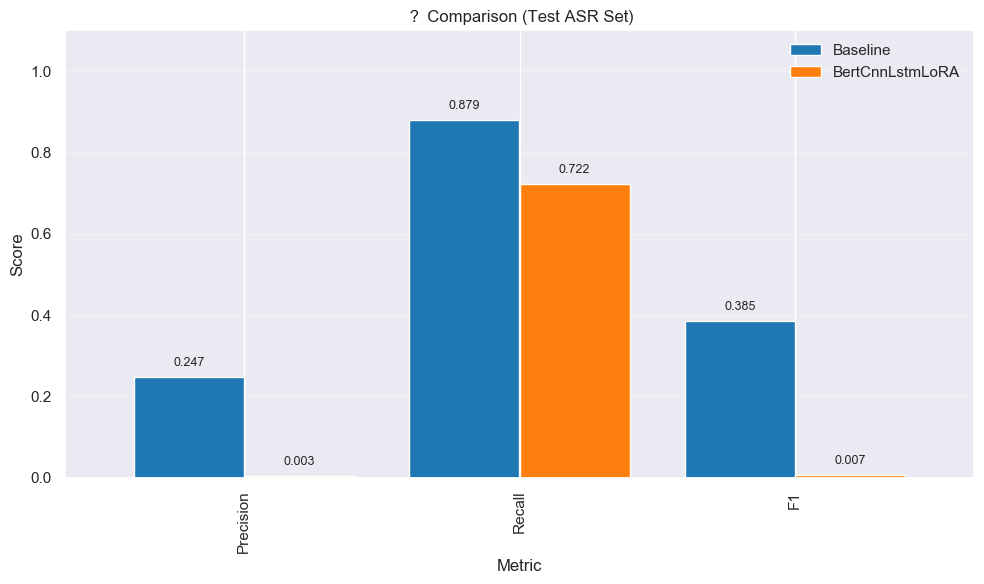

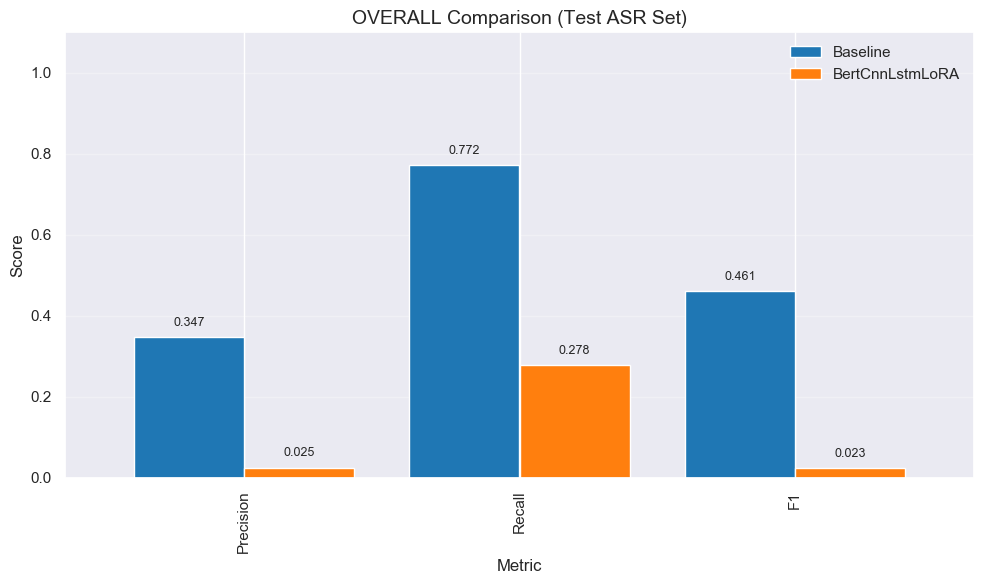

In [61]:
# Comparison bar charts for ASR test set
for col in eval_baseline_asr.columns:
    comparison_df = pd.DataFrame({
        'Baseline': eval_baseline_asr[col],
        'BertCnnLstmLoRA': eval_adapter_asr[col]
    }, index=['Precision', 'Recall', 'F1'])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    comparison_df.plot.bar(ax=ax, width=0.8, color=['#1f77b4', '#ff7f0e'])
    ax.set_title(f'{col} Comparison (Test ASR Set)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xlabel('Metric', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.1])
    
    # Add value labels on bars
    for i, (baseline_val, adapter_val) in enumerate(zip(eval_baseline_asr[col], eval_adapter_asr[col])):
        ax.text(i - 0.2, baseline_val + 0.02, f'{baseline_val:.3f}', 
                ha='center', va='bottom', fontsize=9)
        ax.text(i + 0.2, adapter_val + 0.02, f'{adapter_val:.3f}', 
                ha='center', va='bottom', fontsize=9)
    
    # Set font for x-axis labels if Chinese font is available
    if chinese_font_name and col in ['，', '。', '？']:
        font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=12)
        ax.set_title(f'{col} Comparison (Test ASR Set)', fontsize=14, fontweight='bold', 
                    fontproperties=font_prop_with_size)
    
    plt.tight_layout()
    plt.show()


## Confusion Matrices


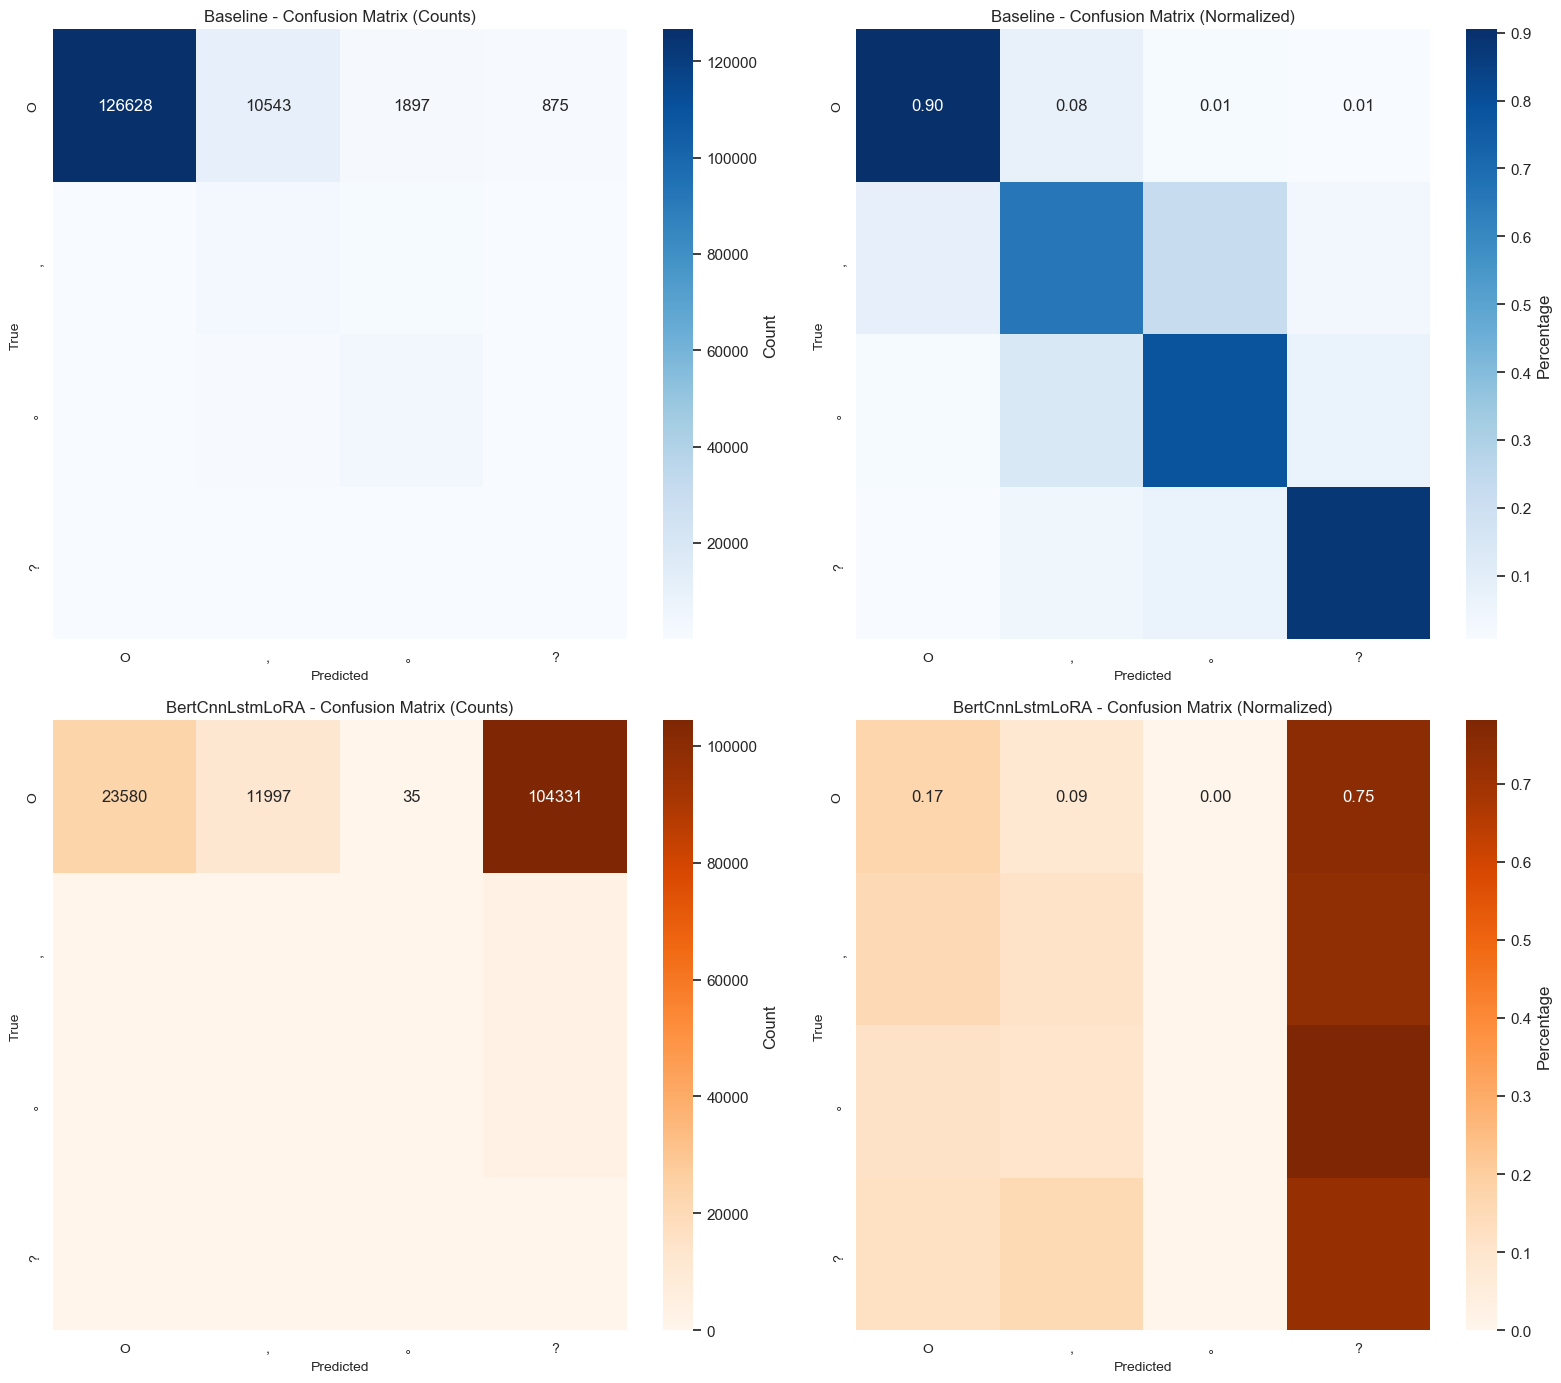

In [62]:
from sklearn.metrics import confusion_matrix

label_keys = list(punctuation_enc.keys())
label_vals = list(punctuation_enc.values())

# Confusion matrices for test set
cm_baseline = confusion_matrix(y_true_baseline, y_pred_baseline, labels=label_vals)
cm_adapter = confusion_matrix(y_true_adapter, y_pred_adapter, labels=label_vals)

# Normalize
cm_baseline_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
cm_adapter_norm = cm_adapter.astype('float') / cm_adapter.sum(axis=1)[:, np.newaxis]

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Baseline - Raw counts
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_keys, yticklabels=label_keys, 
            ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title('Baseline - Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted', fontsize=10)
axes[0, 0].set_ylabel('True', fontsize=10)
if chinese_font_name:
    font_prop_cm = fm.FontProperties(family=chinese_font_name, size=10)
    axes[0, 0].set_xticklabels(label_keys, fontproperties=font_prop_cm)
    axes[0, 0].set_yticklabels(label_keys, fontproperties=font_prop_cm)

# Baseline - Normalized
sns.heatmap(cm_baseline_norm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=label_keys, yticklabels=label_keys, 
            ax=axes[0, 1], cbar_kws={'label': 'Percentage'})
axes[0, 1].set_title('Baseline - Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontsize=10)
axes[0, 1].set_ylabel('True', fontsize=10)
if chinese_font_name:
    axes[0, 1].set_xticklabels(label_keys, fontproperties=font_prop_cm)
    axes[0, 1].set_yticklabels(label_keys, fontproperties=font_prop_cm)

# Adapter - Raw counts
sns.heatmap(cm_adapter, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=label_keys, yticklabels=label_keys, 
            ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_title('BertCnnLstmLoRA - Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted', fontsize=10)
axes[1, 0].set_ylabel('True', fontsize=10)
if chinese_font_name:
    axes[1, 0].set_xticklabels(label_keys, fontproperties=font_prop_cm)
    axes[1, 0].set_yticklabels(label_keys, fontproperties=font_prop_cm)

# Adapter - Normalized
sns.heatmap(cm_adapter_norm, annot=True, fmt='.2f', cmap='Oranges', 
            xticklabels=label_keys, yticklabels=label_keys, 
            ax=axes[1, 1], cbar_kws={'label': 'Percentage'})
axes[1, 1].set_title('BertCnnLstmLoRA - Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicted', fontsize=10)
axes[1, 1].set_ylabel('True', fontsize=10)
if chinese_font_name:
    axes[1, 1].set_xticklabels(label_keys, fontproperties=font_prop_cm)
    axes[1, 1].set_yticklabels(label_keys, fontproperties=font_prop_cm)

plt.tight_layout()
plt.show()


## Summary Comparison Table


In [63]:
# Create comprehensive comparison table
comparison_data = {
    'Metric': ['Precision', 'Recall', 'F1'],
    'Baseline (，)': [eval_baseline['，']['Precision'], eval_baseline['，']['Recall'], eval_baseline['，']['F1']],
    'BertCnnLstmLoRA (，)': [eval_adapter['，']['Precision'], eval_adapter['，']['Recall'], eval_adapter['，']['F1']],
    'Baseline (。)': [eval_baseline['。']['Precision'], eval_baseline['。']['Recall'], eval_baseline['。']['F1']],
    'BertCnnLstmLoRA (。)': [eval_adapter['。']['Precision'], eval_adapter['。']['Recall'], eval_adapter['。']['F1']],
    'Baseline (？)': [eval_baseline['？']['Precision'], eval_baseline['？']['Recall'], eval_baseline['？']['F1']],
    'BertCnnLstmLoRA (？)': [eval_adapter['？']['Precision'], eval_adapter['？']['Recall'], eval_adapter['？']['F1']],
    'Baseline (OVERALL)': [eval_baseline['OVERALL']['Precision'], eval_baseline['OVERALL']['Recall'], eval_baseline['OVERALL']['F1']],
    'BertCnnLstmLoRA (OVERALL)': [eval_adapter['OVERALL']['Precision'], eval_adapter['OVERALL']['Recall'], eval_adapter['OVERALL']['F1']],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('Metric', inplace=True)

print("=" * 80)
print("Comprehensive Comparison (Test Set)")
print("=" * 80)
display(comparison_df.round(4))

# Calculate accuracy
baseline_accuracy = metrics.accuracy_score(y_true_baseline, y_pred_baseline)
adapter_accuracy = metrics.accuracy_score(y_true_adapter, y_pred_adapter)

print(f"\nOverall Accuracy:")
print(f"  Baseline: {baseline_accuracy:.4f}")
print(f"  BertCnnLstmLoRA: {adapter_accuracy:.4f}")
print(f"  Improvement: {adapter_accuracy - baseline_accuracy:+.4f}")


Comprehensive Comparison (Test Set)


,Baseline (，),BertCnnLstmLoRA (，),Baseline (。),BertCnnLstmLoRA (。),Baseline (？),BertCnnLstmLoRA (？),Baseline (OVERALL),BertCnnLstmLoRA (OVERALL)
Metric,,,,,,,,
Precision,0.2325,0.0439,0.5633,0.0278,0.2466,0.0033,0.3475,0.0250
Recall,0.6575,0.1112,0.7798,0.0002,0.8794,0.7218,0.7722,0.2777
F1,0.3436,0.0629,0.6541,0.0004,0.3852,0.0066,0.4609,0.0233



Overall Accuracy:
  Baseline: 0.8920
  BertCnnLstmLoRA: 0.1627
  Improvement: -0.7293
